# Assessment 2: ANN Classification Performance on the FER-2013 Dataset
This notebook builds an ANN baseline and creates a shared train/val/test split for fair comparison with a CNN.

## 1. Imports and Configuration
This section imports required libraries and sets global constants for reproducibility and fairness.

In [12]:
# Core utilities
import pathlib
import random

# Numerical work
import numpy as np

# Deep learning framework
import tensorflow as tf

# Plotting
import matplotlib.pyplot as plt

# Splitting + metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Reproducibility / Fairness
# -----------------------------
# Fix seeds so that the split and training are repeatable
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Paths / Data Settings
# -----------------------------
# Base FER directory that already contains train/ and test/
DATA_DIR = pathlib.Path("./data/fer-2013")

# Training and test folder locations
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

# File we save so BOTH notebooks use identical arrays
SPLITS_PATH = pathlib.Path("./fer-2013_splits.npz")

# FER-2013 images are 48x48 grayscale
IMG_SIZE = (48, 48)

# Training hyperparameters (kept identical for ANN and CNN)
BATCH_SIZE = 64
EPOCHS = 40
LEARNING_RATE = 1e-3

## 2. Load Dataset from Directory
This section loads all FER-2013 training images from the train/ directory into memory.

In [13]:
# Ensure the train folder exists before loading
if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR.resolve()}")

# Load ALL training images using folder labels
# batch_size=None means we get an unbatched dataset so we can split ourselves
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",        # infer labels from subfolder names
    label_mode="int",         # labels as integer indices
    color_mode="grayscale",   # FER-2013 is grayscale
    image_size=IMG_SIZE,      # force 48x48
    batch_size=None,          # keep unbatched for splitting
    shuffle=True,
    seed=SEED
)

# Store class names in consistent order
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Convert tf.data dataset into NumPy arrays
X_train_all, y_train_all = [], []
for x, y in train_ds:
    X_train_all.append(x.numpy())   # image
    y_train_all.append(y.numpy())   # label

# Stack into final tensors
X_train_all = np.stack(X_train_all)          # shape: (N, 48, 48, 1)
y_train_all = np.array(y_train_all).astype(int)

print("Train-all:", X_train_all.shape, y_train_all.shape)

Found 28709 files belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


2025-11-24 17:31:02.665614: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train-all: (28709, 48, 48, 1) (28709,)


## 3. Create and Save Shared Train/Val Split + Load Test
This section creates a stratified train/val split from train/ and loads test/ untouched.

In [14]:
# Only create splits if we haven't already saved them
if SPLITS_PATH.exists():
    print("Split file already exists. Skipping creation.")
else:
    # -----------------------------
    # 1) Split TRAIN into train/val
    # -----------------------------
    # We split ONLY the official training set to create a validation set for early stopping
    # Stratify so each emotion keeps its proportion in both sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.20,           # 80% train / 20% validation
        random_state=SEED,
        stratify=y_train_all
    )

    # -----------------------------
    # 2) Load TEST set untouched
    # -----------------------------
    if not TEST_DIR.exists():
        raise FileNotFoundError(f"TEST_DIR not found: {TEST_DIR.resolve()}")

    # shuffle=False because test should be stable and not mixed
    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=None,
        shuffle=False
    )

    # Convert test dataset into NumPy arrays
    X_test, y_test = [], []
    for x, y in test_ds:
        X_test.append(x.numpy())
        y_test.append(y.numpy())

    X_test = np.stack(X_test)
    y_test = np.array(y_test).astype(int)

    # -----------------------------
    # 3) Normalise pixel intensities
    # -----------------------------
    # Convert to float32 and scale [0,255] -> [0,1]
    X_train = X_train.astype("float32") / 255.0
    X_val   = X_val.astype("float32") / 255.0
    X_test  = X_test.astype("float32") / 255.0

    # -----------------------------
    # 4) Save shared split file
    # -----------------------------
    # This guarantees ANN and CNN train on EXACTLY the same arrays
    np.savez(
        SPLITS_PATH,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        class_names=np.array(class_names)
    )

    print("Saved splits to:", SPLITS_PATH.resolve())

Found 5583 files belonging to 7 classes.


2025-11-24 17:31:05.884136: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Saved splits to: /Users/monty/Library/CloudStorage/OneDrive-BathSpaUniversity/GitHub Repositories/MacBook/artificial-intelligence-25-26/Assessments/Assessment-2-Machine-Learning/fer-2013_splits.npz


## 4. Load Shared Splits
This section loads the saved splits to guarantee fairness across models.

In [15]:
# Load shared arrays saved in Cell 7
splits = np.load(SPLITS_PATH, allow_pickle=True)

# Unpack splits
X_train, y_train = splits["X_train"], splits["y_train"]
X_val, y_val     = splits["X_val"], splits["y_val"]
X_test, y_test   = splits["X_test"], splits["y_test"]

# Recover class ordering used by folder loader
class_names = splits["class_names"].tolist()
num_classes = len(class_names)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (22967, 48, 48, 1)
Val:   (5742, 48, 48, 1)
Test:  (5583, 48, 48, 1)


## 5. Compute Class Weights
This section creates balanced class weights to reduce the impact of FER-2013 class imbalance.

In [16]:
# FER-2013 is imbalanced (e.g., "disgust" is rare)
# This builds weights so rare classes contribute more to loss
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# Keras expects a dict {class_index: weight}
class_weights = dict(enumerate(cw))
print("Class weights:", class_weights)

Class weights: {0: 1.0265957446808511, 1: 9.401146131805158, 2: 1.0012206286237413, 3: 0.5684338184338185, 4: 0.8260322255790534, 5: 0.849120082815735, 6: 1.2932597556168703}


## 6. Flatten Images for ANN
This section reshapes each image into a vector suitable for a fully connected network.

In [17]:
# ANN baseline uses fully-connected layers, so inputs must be 1D
# 48x48 = 2304 features per image
X_train_f = X_train.reshape(len(X_train), -1)
X_val_f   = X_val.reshape(len(X_val), -1)
X_test_f  = X_test.reshape(len(X_test), -1)

print("Flattened train shape:", X_train_f.shape)

Flattened train shape: (22967, 2304)


## 7. Build and Compile ANN
This section defines a simple ANN baseline aligned with taught content.

In [18]:
def build_ann(input_dim, num_classes):
    """
    Simple feed-forward ANN:
    - Dense layers learn global pixel relationships.
    - Dropout helps reduce overfitting (common on FER).
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),

        tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.4),

        # 7-class softmax output
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    return model

# Build model using flattened feature dimension
ann = build_ann(X_train_f.shape[1], num_classes)

# Compile with same optimiser/lr as CNN for fairness
ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,287 (5.01 MB)

 Trainable params: 1,313,287 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train The ANN
This section trains the ANN using early stopping and class weights for stability.

In [19]:
# Early stopping prevents wasting epochs once validation stops improving
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )
]

# Train with class weights so minority classes matter
history = ann.fit(
    X_train_f, y_train,
    validation_data=(X_val_f, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.1424 - loss: 24.5984 - val_accuracy: 0.1682 - val_loss: 5.0364
Epoch 2/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.1443 - loss: 14.3988 - val_accuracy: 0.1855 - val_loss: 2.6301
Epoch 3/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.1396 - loss: 5.4160 - val_accuracy: 0.1392 - val_loss: 2.2316
Epoch 4/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.1352 - loss: 3.3744 - val_accuracy: 0.1928 - val_loss: 1.9600
Epoch 5/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.1362 - loss: 2.9213 - val_accuracy: 0.1392 - val_loss: 2.2911
Epoch 6/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.1364 - loss: 2.8846 - val_accuracy: 0.1392 - val_loss: 2.1832
Epoch 7/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.1387 - loss: 2.8261 - val_accuracy: 0.2511 - val_loss: 2.1217
Epoch 8/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.1375 - loss: 2.9826 - va

## 9. Evaluate ANN
This section reports test performance and a confusion matrix for later comparison.

ANN Test Accuracy: 0.1558
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

       angry       0.02      0.53      0.04       116
     disgust       0.00      0.00      0.00         1
        fear       0.00      0.00      0.00      1024
       happy       0.28      0.49      0.36      1636
     neutral       1.00      0.00      0.00      1229
         sad       0.00      0.00      0.00       746
    surprise       0.00      0.00      0.00       831

    accuracy                           0.16      5583
   macro avg       0.19      0.15      0.06      5583
weighted avg       0.30      0.16      0.11      5583



/Users/monty/Library/CloudStorage/OneDrive-BathSpaUniversity/GitHub Repositories/MacBook/artificial-intelligence-25-26/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/monty/Library/CloudStorage/OneDrive-BathSpaUniversity/GitHub Repositories/MacBook/artificial-intelligence-25-26/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/monty/Library/CloudStorage/OneDrive-BathSpaUniversity/GitHub Repositories/MacBook/artificial-intelligence-25-26/.venv/lib/p

<Figure size 700x700 with 0 Axes>

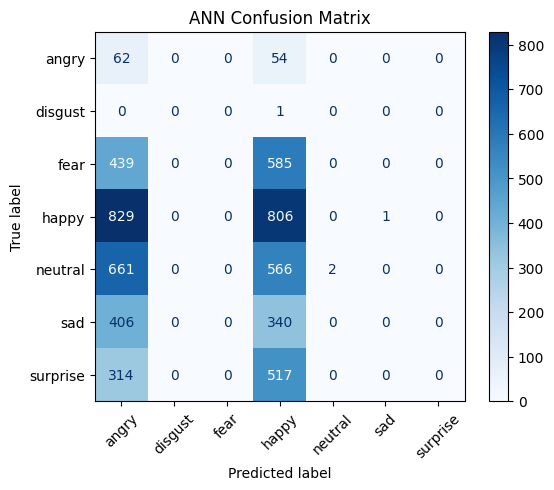

In [20]:
# Evaluate on held-out test set (never seen during training/validation)
test_loss, test_acc = ann.evaluate(X_test_f, y_test, verbose=0)
print(f"ANN Test Accuracy: {test_acc:.4f}")

# Predict class probabilities then take argmax for labels
y_pred = np.argmax(ann.predict(X_test_f), axis=1)

# Detailed precision/recall/F1 per class
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix for error analysis
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

plt.figure(figsize=(7, 7))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("ANN Confusion Matrix")
plt.show()

In [21]:
import os
from collections import Counter

def count_images(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith((".png",".jpg",".jpeg"))
            ])
    return counts

print("TRAIN counts:")
print(count_images(TRAIN_DIR))

print("\nTEST counts:")
print(count_images(TEST_DIR))

TRAIN counts:
{'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 830, 'neutral': 4965, 'sad': 2198, 'surprise': 3171}

TEST counts:
{'angry': 116, 'disgust': 0, 'fear': 1024, 'happy': 1636, 'neutral': 1229, 'sad': 746, 'surprise': 831}
